In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("insurance.csv")


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [4]:
df.shape

(1340, 10)

In [5]:
pd.set_option("display.float_format","{:.2f}".format)

In [6]:
sns.set(style="whitegrid", palette="Set2", font_scale=1.1)

In [7]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [12]:
df.dropna(inplace= True)

In [13]:
df.shape

(1332, 10)

In [14]:
df.isna().sum().sum()

np.int64(0)

In [16]:
df.describe(include= "all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


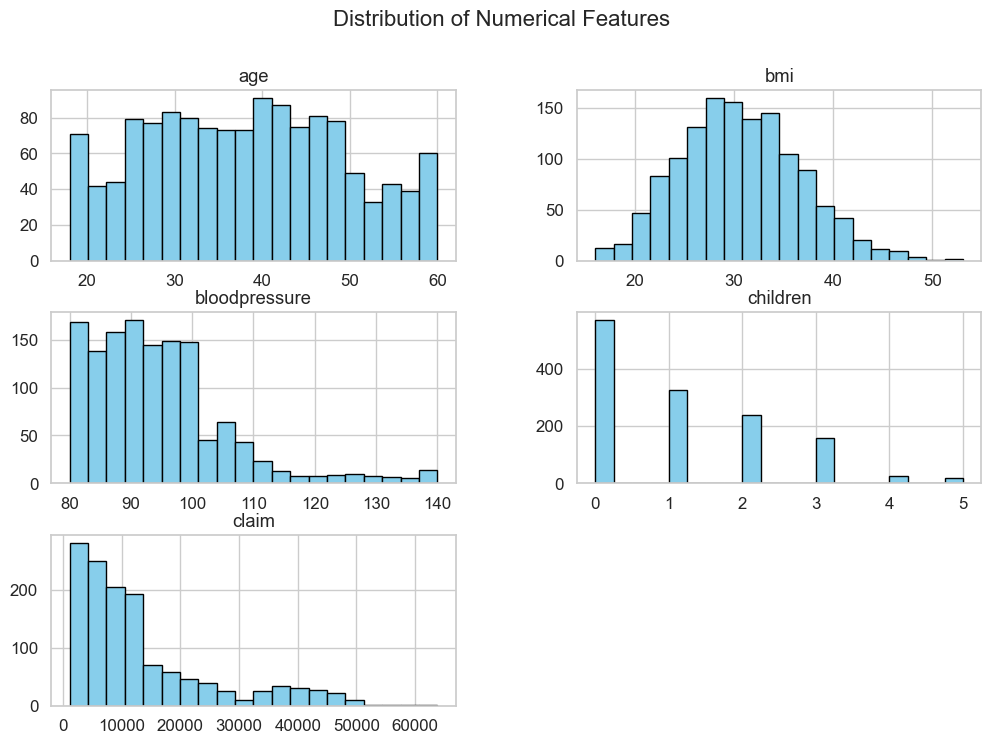

In [17]:
numeric_cols = ["age", "bmi","bloodpressure", "children", "claim"]

df [numeric_cols].hist(bins=20, figsize=(12,8), color = "skyblue", edgecolor = "black")
plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.show()

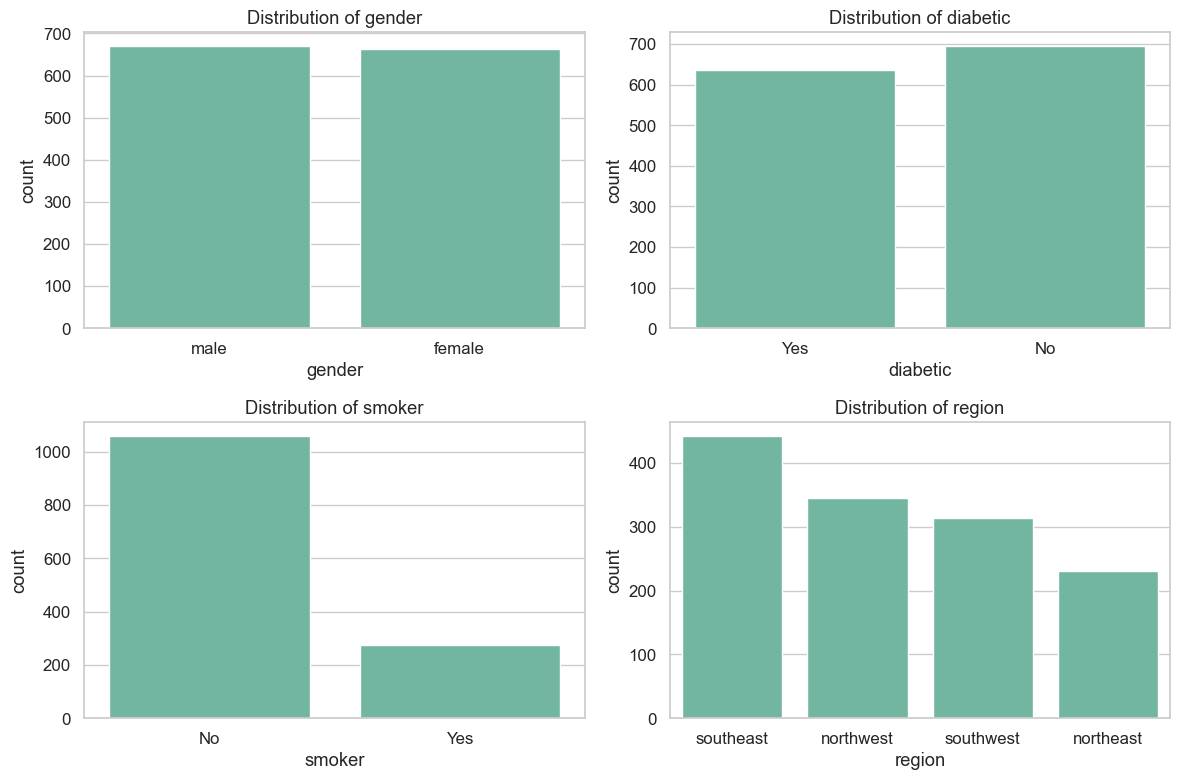

In [18]:
cat_cols = ["gender", "diabetic", "smoker", "region"]

plt.figure(figsize=(12,8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [19]:
df.groupby(["gender", "smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

In [25]:
pivot_region_diabetic=df. groupby(["region","diabetic"])["claim"].mean().unstack()

In [26]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


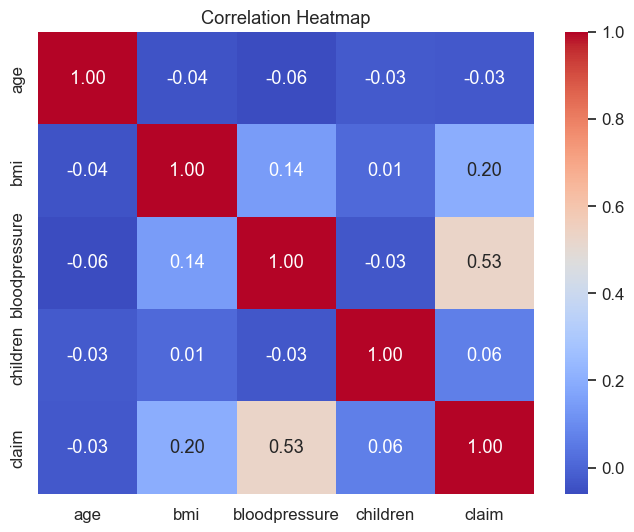

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [48]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim', 'age_group', 'bmi_category'],
      dtype='object')

In [51]:
X = df[["age","gender","bmi","bloodpressure","diabetic","children","smoker"]]
y = df["claim"]

In [52]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,male,23.20,91,Yes,0,No
1,24.00,male,30.10,87,No,0,No
7,19.00,male,41.10,100,No,0,No
8,20.00,male,43.00,86,No,0,No
9,30.00,male,53.10,97,No,0,No
...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes
1336,59.00,female,38.10,120,No,1,Yes
1337,30.00,male,34.50,91,Yes,3,Yes
1338,37.00,male,30.40,106,No,0,Yes


In [53]:
cat_cols = ["gender", "diabetic","smoker"]
label_encoders = {}

In [54]:
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

    joblib.dump(le, f"label_encoder_{col}.pkl")

C:\Users\biswa\AppData\Local\Temp\ipykernel_28412\1530066519.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\biswa\AppData\Local\Temp\ipykernel_28412\1530066519.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
C:\Users\biswa\AppData\Local\Temp\ipykernel_28412\1530066519.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [55]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,1,23.20,91,1,0,0
1,24.00,1,30.10,87,0,0,0
7,19.00,1,41.10,100,0,0,0
8,20.00,1,43.00,86,0,0,0
9,30.00,1,53.10,97,0,0,0
...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1
1336,59.00,0,38.10,120,0,1,1
1337,30.00,1,34.50,91,1,3,1
1338,37.00,1,30.40,106,0,0,1


In [56]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [58]:
num_cols = ["age", "bmi", "bloodpressure","children"]
scaler = StandardScaler()

In [59]:
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [60]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [61]:
print(X_train.shape, y_train.shape)

(1065, 7) (1065,)


In [62]:
print(X_test.shape, y_test.shape)

(267, 7) (267,)


In [66]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

In [73]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return {"R2": r2, "MAE": mae, "RMSE": rmse}

In [74]:
results = {}

In [76]:
rf = RandomForestRegressor()

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(rf, rf_params,cv=3,scoring="r2",n_jobs=-1,    verbose=1)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

results["Random Forest"] = evaluate_model (  best_rf,X_train, X_test,y_train,y_test)

print("Random Forest training is completed, best parameters:", rf_grid.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Random Forest training is completed, best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [77]:
results["Random Forest"]


{'R2': 0.8069468597501577,
 'MAE': 3977.1575180443733,
 'RMSE': np.float64(5217.715434708644)}

In [78]:
import pandas as pd
pd.DataFrame(results).T

,R2,MAE,RMSE
Random Forest,0.81,3977.16,5217.72


In [79]:
joblib.dump(best_rf, "insurance_random_forest_model.pkl")

['insurance_random_forest_model.pkl']

In [80]:
predictions = best_rf.predict(X_test)
print(predictions[:10])

[ 9336.77832543  6613.56574367  8525.23445884  8295.62791631
  7375.46367298  6996.16144327  7626.10334683  5769.70215575
 14392.2332634   8449.18887961]


In [81]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

print(comparison.head())

      Actual  Predicted
377  5246.05    9336.78
891 12741.17    6613.57
440  6184.30    8525.23
983 15019.76    8295.63
708  9877.61    7375.46


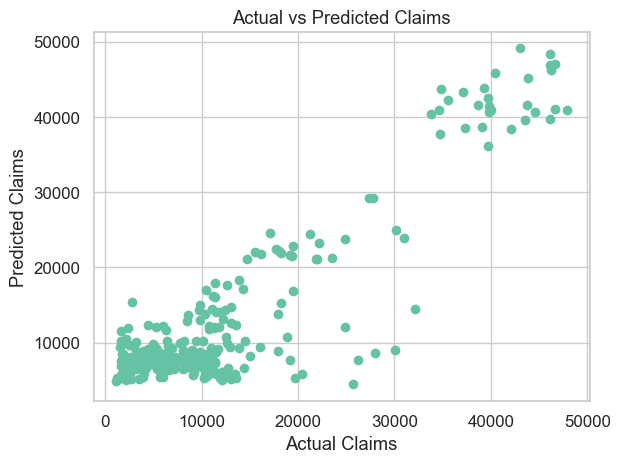

In [82]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Claims")
plt.ylabel("Predicted Claims")
plt.title("Actual vs Predicted Claims")
plt.show()

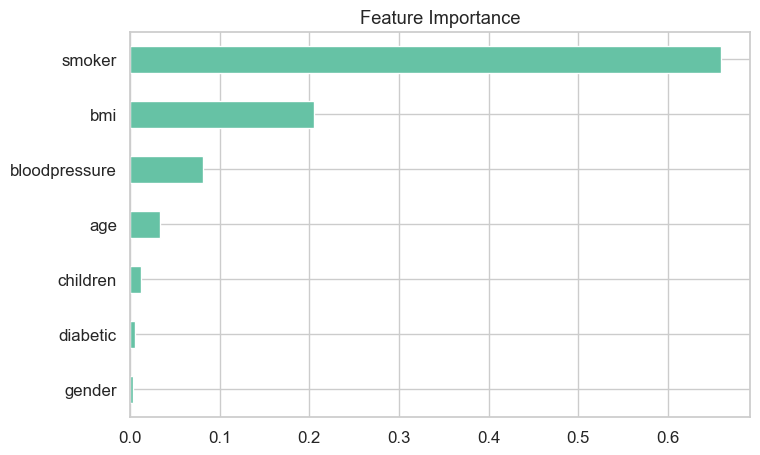

In [83]:
importance = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance")
plt.show()